Completed simulations: 54
                  ID     Material  Applied_Load_Pa  Deformation_mm  Stress_MPa
  BL0.8_C150_AL_P500    Aluminium              500         2.43760      4.2995
 BL0.8_C150_AL_P1000    Aluminium             1000         4.87520      8.5991
 BL0.8_C150_AL_P1500    Aluminium             1500         7.31290     12.8990
 BL0.8_C150_FBG_P500   Fiberglass              500         6.74170      4.3042
BL0.8_C150_FBG_P1000   Fiberglass             1000        13.48300      8.6085
BL0.8_C150_FBG_P1500   Fiberglass             1500        20.22500     12.9130
 BL0.8_C150_CBF_P500 Carbon fiber              500         1.40310      4.3016
BL0.8_C150_CBF_P1000 Carbon fiber             1000         2.80610      8.6032
BL0.8_C150_CBF_P1500 Carbon fiber             1500         4.20920     12.9050
  BL0.8_C200_AL_P500    Aluminium              500         1.07480      2.3977
 BL0.8_C200_AL_P1000    Aluminium             1000         2.14960      4.7955
 BL0.8_C200_AL_P1500    Al

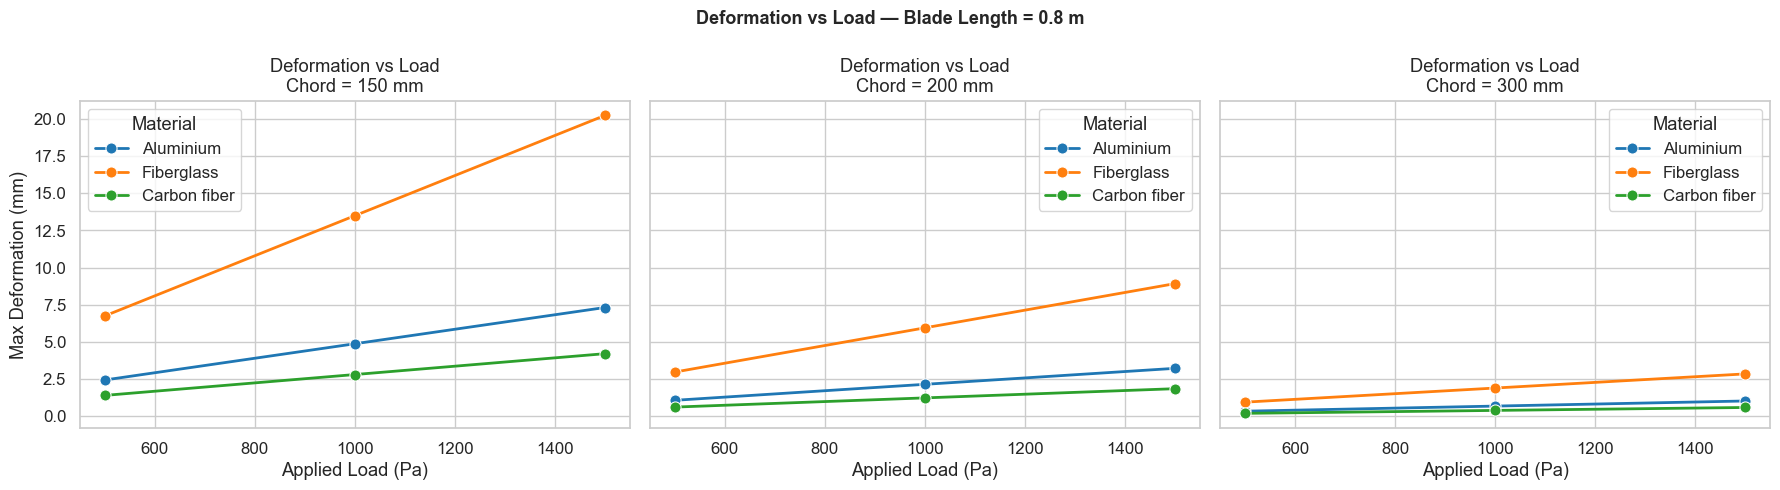

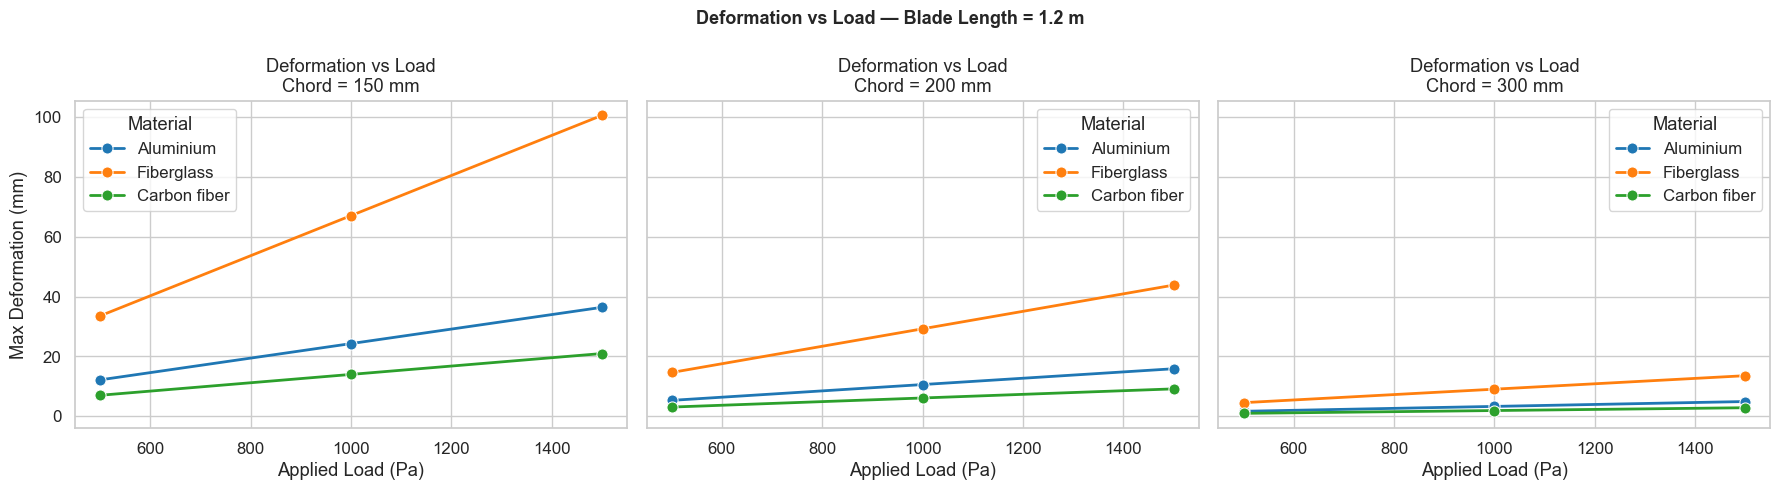

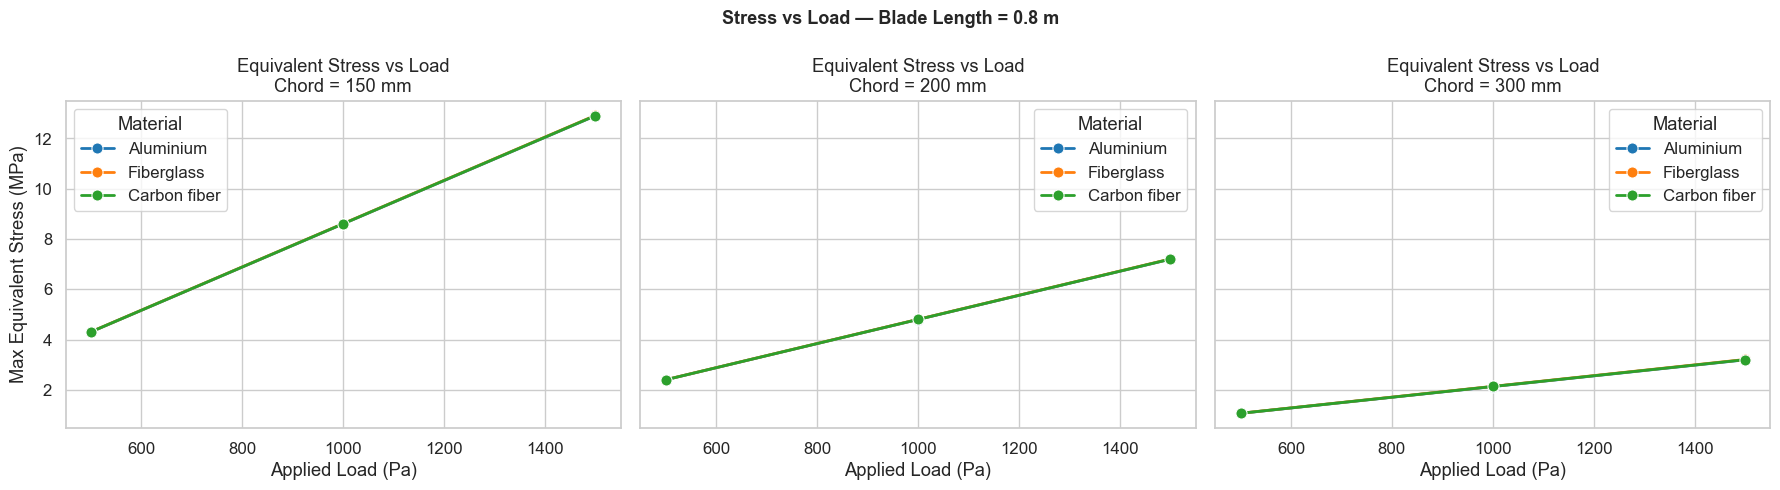

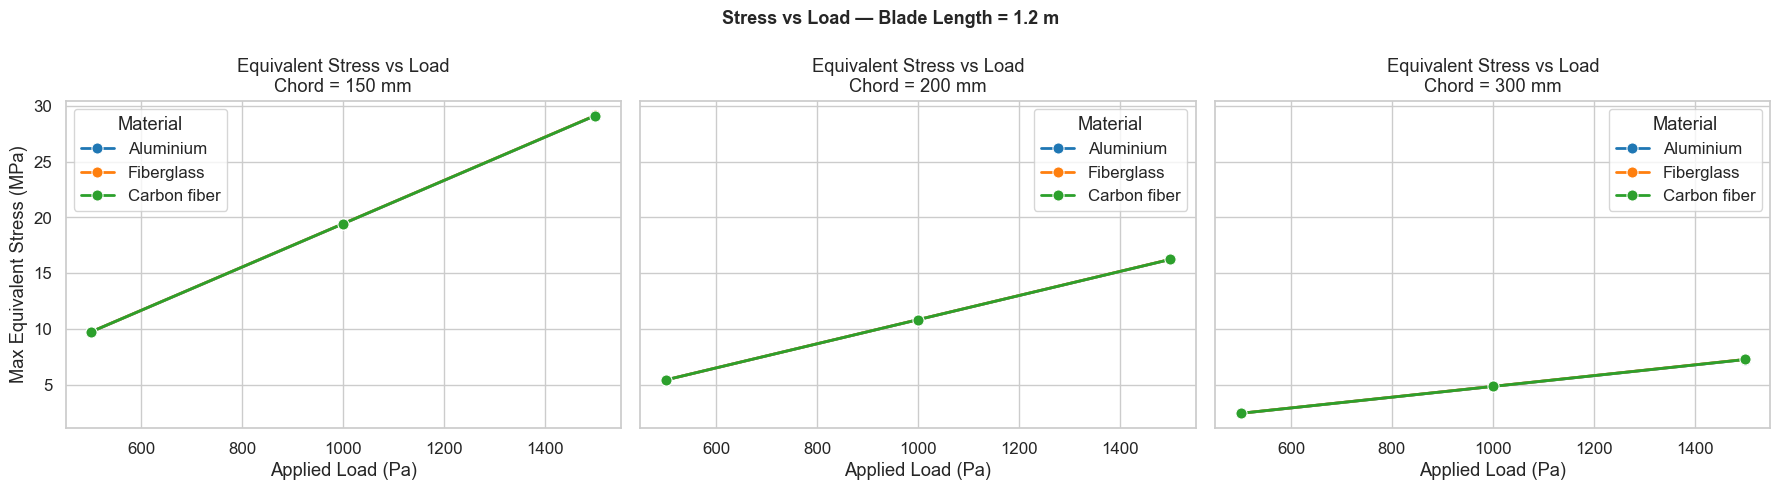

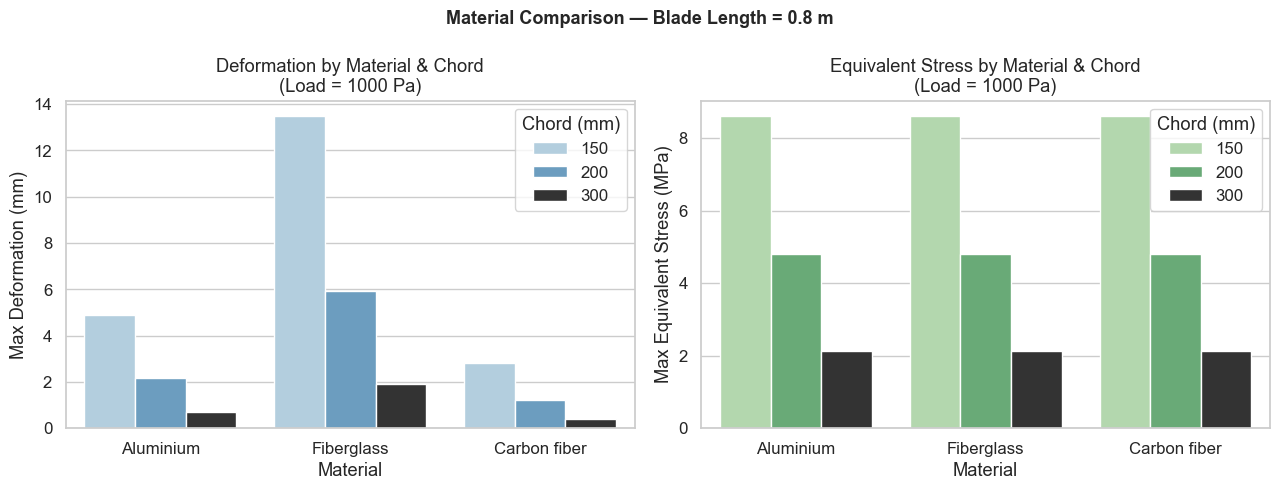

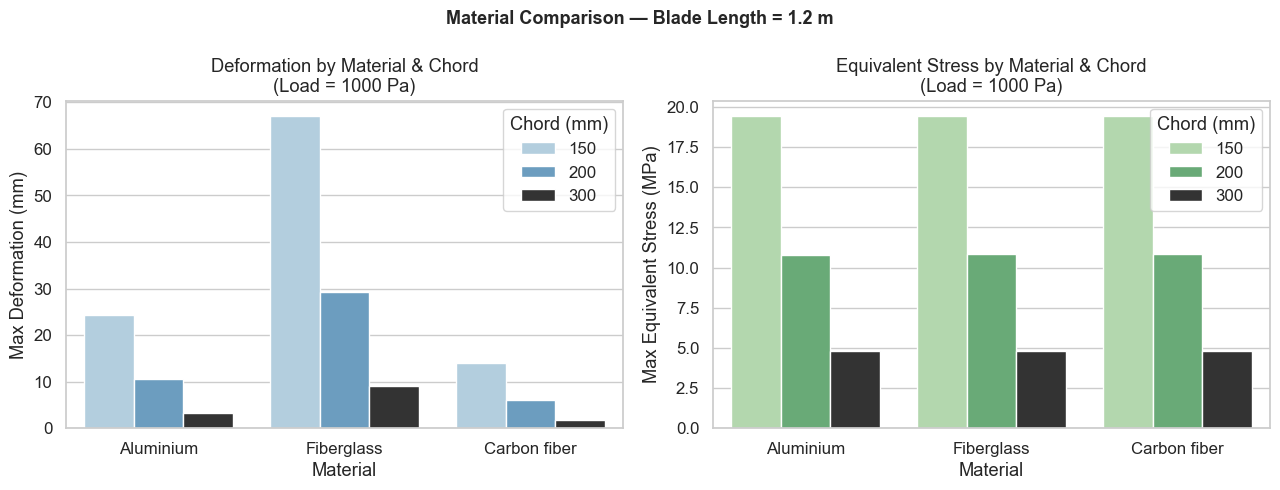

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\Dataset\simulation_matrix_updated_info.csv"
sim_data = pd.read_csv(path)

# Clean up stress column
sim_data["Max_Equiv_Stress_Pa"] = sim_data["Max_Equiv_Stress_Pa"].astype(str).str.replace(" ", "")

# Filter to completed rows only
sim_data_done = sim_data[sim_data["Status"] == "Updated"].copy()
sim_data_done["Max_Deformation_m"] = pd.to_numeric(sim_data_done["Max_Deformation_m"])
sim_data_done["Max_Equiv_Stress_Pa"] = pd.to_numeric(sim_data_done["Max_Equiv_Stress_Pa"])

# Convenient unit conversions for plotting
sim_data_done["Deformation_mm"] = sim_data_done["Max_Deformation_m"] * 1000
sim_data_done["Stress_MPa"] = sim_data_done["Max_Equiv_Stress_Pa"] / 1e6

print(f"Completed simulations: {len(sim_data_done)}")
print(sim_data_done[["ID", "Material", "Applied_Load_Pa", "Deformation_mm", "Stress_MPa"]].to_string(index=False))

blade_lengths = sorted(sim_data_done["Blade_Length_m"].unique())
#Deformation vs Load — by Material, faceted by Chord Length
# use of AI to polish graphs
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

for blade_length in blade_lengths:
    subset_bl = sim_data_done[sim_data_done["Blade_Length_m"] == blade_length]
    chord_lengths = sorted(subset_bl["Root_Chord_mm"].unique())
    n = len(chord_lengths)

    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, chord in zip(axes, chord_lengths):
        subset = subset_bl[subset_bl["Root_Chord_mm"] == chord]
        sns.lineplot(data=subset, x="Applied_Load_Pa", y="Deformation_mm",
                     hue="Material", marker="o", ax=ax, linewidth=2, markersize=8)
        ax.set_title(f"Deformation vs Load\nChord = {chord} mm")
        ax.set_xlabel("Applied Load (Pa)")
        ax.set_ylabel("Max Deformation (mm)")

    fig.suptitle(f"Deformation vs Load — Blade Length = {blade_length} m", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


#Stress vs Load — by Material, faceted by Chord Length

for blade_length in blade_lengths:
    subset_bl = sim_data_done[sim_data_done["Blade_Length_m"] == blade_length]
    chord_lengths = sorted(subset_bl["Root_Chord_mm"].unique())
    n = len(chord_lengths)

    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, chord in zip(axes, chord_lengths):
        subset = subset_bl[subset_bl["Root_Chord_mm"] == chord]
        sns.lineplot(data=subset, x="Applied_Load_Pa", y="Stress_MPa",
                     hue="Material", marker="o", ax=ax, linewidth=2, markersize=8)
        ax.set_title(f"Equivalent Stress vs Load\nChord = {chord} mm")
        ax.set_xlabel("Applied Load (Pa)")
        ax.set_ylabel("Max Equivalent Stress (MPa)")

    fig.suptitle(f"Stress vs Load — Blade Length = {blade_length} m", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# The lines overlap each other as stress doesn't depend on E (stiffness), rest everything is identical in all three cases

# material comparison at fixed load (1000 Pa) — bar chart

for blade_length in blade_lengths:
    subset_bl = sim_data_done[(sim_data_done["Blade_Length_m"] == blade_length) &
                                  (sim_data_done["Applied_Load_Pa"] == 1000)]
    chord_lengths = sorted(subset_bl["Root_Chord_mm"].unique())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.barplot(data=subset_bl, x="Material", y="Deformation_mm",
                hue="Root_Chord_mm", ax=axes[0], palette="Blues_d")
    axes[0].set_title("Deformation by Material & Chord\n(Load = 1000 Pa)")
    axes[0].set_xlabel("Material")
    axes[0].set_ylabel("Max Deformation (mm)")
    axes[0].legend(title="Chord (mm)")

    sns.barplot(data=subset_bl, x="Material", y="Stress_MPa",
                hue="Root_Chord_mm", ax=axes[1], palette="Greens_d")
    axes[1].set_title("Equivalent Stress by Material & Chord\n(Load = 1000 Pa)")
    axes[1].set_xlabel("Material")
    axes[1].set_ylabel("Max Equivalent Stress (MPa)")
    axes[1].legend(title="Chord (mm)")

    fig.suptitle(f"Material Comparison — Blade Length = {blade_length} m", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

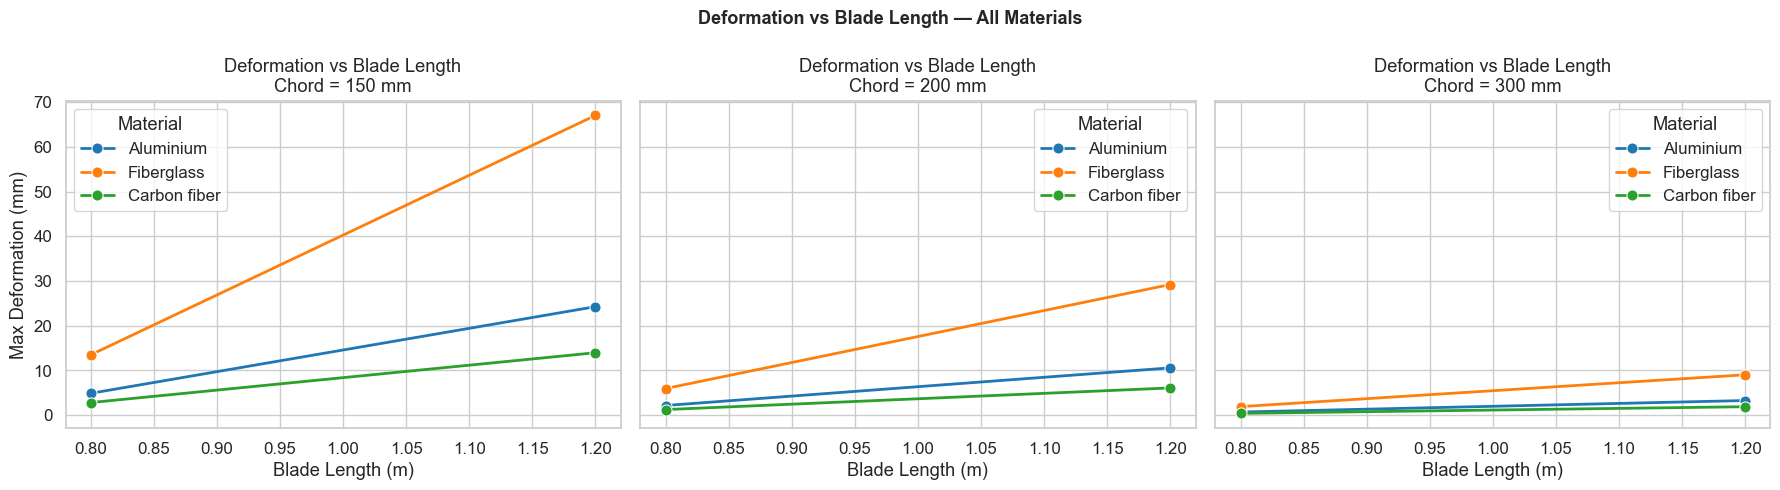

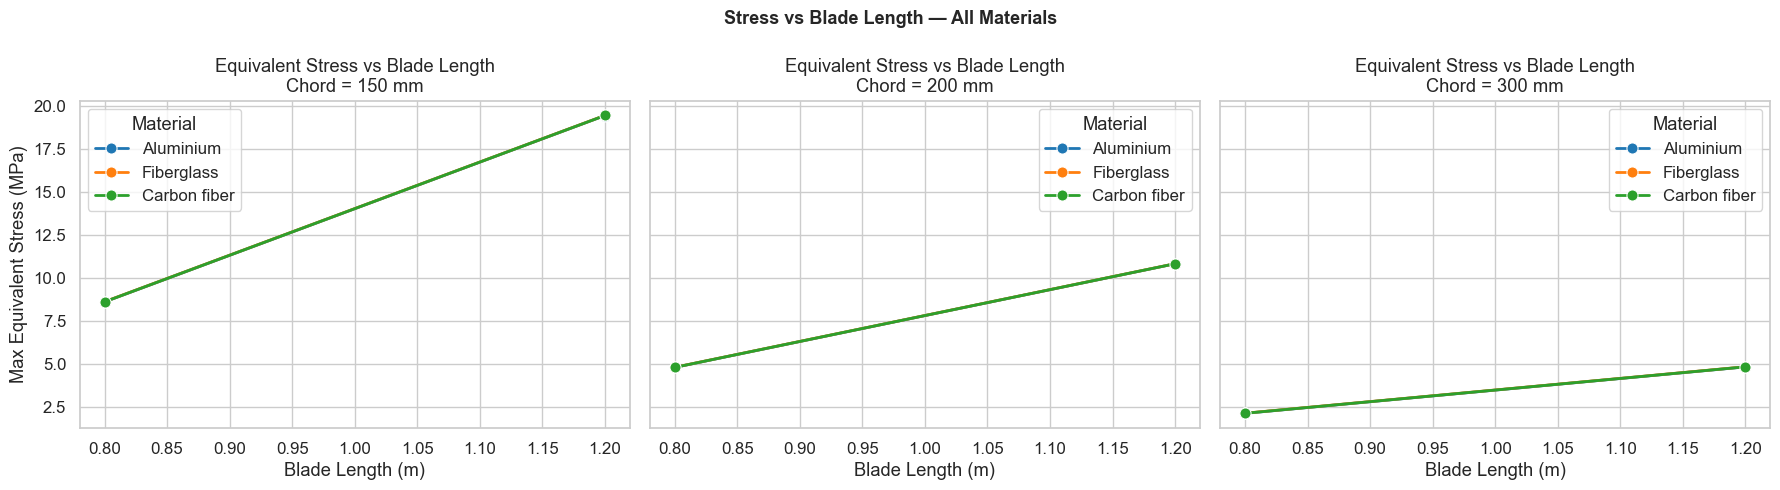

In [14]:
# Keeping 1000 Pa common and fixed in all graphs
# Deformation vs Blade Length — by Material, faceted by Chord Length

chord_lengths = sorted(sim_data_done["Root_Chord_mm"].unique())
n = len(chord_lengths)

fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, chord in zip(axes, chord_lengths):
    subset = sim_data_done[(sim_data_done["Root_Chord_mm"] == chord) &
                       (sim_data_done["Applied_Load_Pa"] == 1000)]
    sns.lineplot(data=subset, x="Blade_Length_m", y="Deformation_mm",
                 hue="Material", marker="o", ax=ax, linewidth=2, markersize=8)
    ax.set_title(f"Deformation vs Blade Length\nChord = {chord} mm")
    ax.set_xlabel("Blade Length (m)")
    ax.set_ylabel("Max Deformation (mm)")

fig.suptitle("Deformation vs Blade Length — All Materials", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Stress vs Blade Length — by Material, faceted by Chord Length

fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, chord in zip(axes, chord_lengths):
    subset = sim_data_done[(sim_data_done["Root_Chord_mm"] == chord) &
                       (sim_data_done["Applied_Load_Pa"] == 1000)]
    sns.lineplot(data=subset, x="Blade_Length_m", y="Stress_MPa",
                 hue="Material", marker="o", ax=ax, linewidth=2, markersize=8)
    ax.set_title(f"Equivalent Stress vs Blade Length\nChord = {chord} mm")
    ax.set_xlabel("Blade Length (m)")
    ax.set_ylabel("Max Equivalent Stress (MPa)")

fig.suptitle("Stress vs Blade Length — All Materials", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()